In [ ]:
#Create plots that compare the results for fitting the BW and Gaussian 
#distributions to the given dataset based on using SciPy's curve fitting,
#and using optimize.minimize with at least two different methods. 
#Compare how the results differ, then discuss how the approaches differ, how fast they converge,
#how sensitive it is to the choice of x0, etc.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

en, f, f_sd = np.loadtxt("data_ch6_resonance.txt")

In [3]:
def breit_wigner(e, params):
    e0, gamma, strength = params
    denom = (e-e0)**2+(gamma**2)/4
    return strength/denom

def breit_wigner_chi(params):
    model=breit_wigner(en, params)
    return np.sum(((f-model)/f_sd)**2)

def gaussian(e, params):
    mu, sigma, A = params
    return A*np.exp(-0.5*((e-mu)/sigma)**2)

def gaussian_chi(params):
    model = gaussian(en,params)
    return np.sum(((f-model)/f_sd)**2)

In [5]:
#Gradient Descent
def grad(phi, x, h=1e-6):
    n = len(x)
    g = np.zeros_like(x)
    fx = phi(x)
    for i in range(n):
        xh = x.copy()
        xh[i] += h
        g[i] = (phi(xh)-fx)/h
    return g

def descent(phi, grad, x0, gamma=1e-5, tol=1e-6, kmax=5000):
    x = x0.copy()
    for k in range(kmax):
        g = grad(phi, x)
        x_new = x - gamma * g
        x_new[1:] = np.clip(x_new[1:], 1e-6, None) 
        if np.linalg.norm(x_new - x)<tol:
            break
        x = x_new
    return x, k+1

In [6]:
x0_bw = np.array([2.5, 0.1, 0.1])
x0_gauss = np.array([2.5, 0.1, 1.0])

In [9]:
#Gradient Descent Fits
bw_gd_params, bw_gd_iter = descent(breit_wigner_chi, grad, x0_bw)
gauss_gd_params, gauss_gd_iter = descent(gaussian_chi, grad, x0_gauss)

#SciPy Minimize Fits
methods = {"Nelder-Mead", "BFGS"}
results = {"Breit-Wigner":{}, "Gaussian": {}}

for model_name, chi_func, x0 in [
  ("Breit-Wigner", breit_wigner_chi, x0_bw),
    ("Gaussian", gaussian_chi, x0_gauss)
]:
    for m in methods:
        res = optimize.minimize(chi_func, x0, method=m)
        results[model_name][m] = res


===Optimization Comparison===
Model          GradientDescentParams                        Chi^2       Iter    OK
--------------------------------------------------------------------------------
Breit-Wigner   GrandientDescent[-1.67875263e+02  1.02488115e+03  2.11359644e-01] 193315.6462    5000Y
Gaussian       GradientDescent[5.70130059e+02 1.00000000e-06 1.00000000e-06] 193316.5399       5Y
Breit-Wigner   Nelder-Mead [2.49990233 0.20619975 0.03438494]     81.4179      88Y
Breit-Wigner   BFGS        [  6.78549849  97.99816589 104.67150405] 166664.0322      75N
Gaussian       Nelder-Mead [2.49887391 0.14836089 2.27890488]  30473.0978      84Y
Gaussian       BFGS        [2.49887583 0.14836216 2.27888189]  30473.0977      12Y


<function matplotlib.pyplot.show(close=None, block=None)>

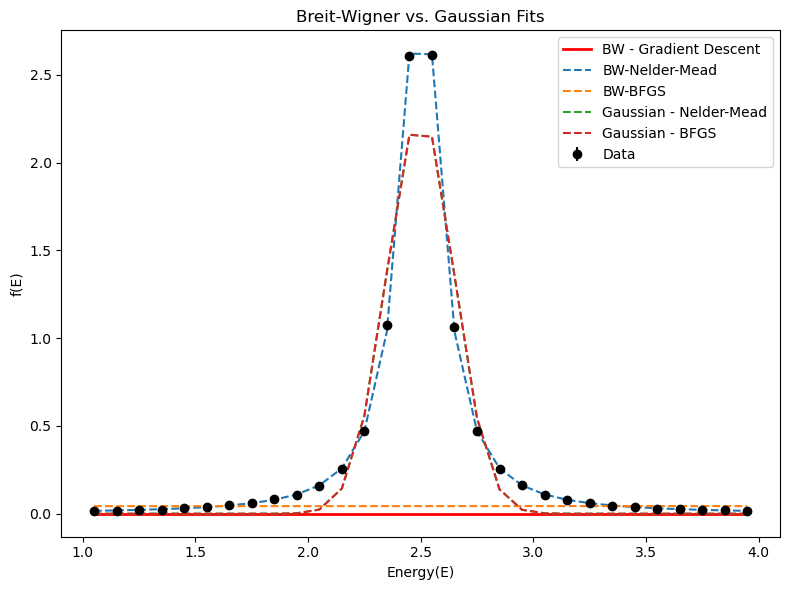

In [19]:
print("\n===Optimization Comparison===")
print(f"{'Model':<15}{'GradientDescent':<12}{'Params':<30}{'Chi^2':<12}{'Iter':<8}{'OK'}")
print("-"*80)
print(f"{'Breit-Wigner':<15}{'GrandientDescent':<12}{bw_gd_params}{breit_wigner_chi(bw_gd_params):12.4f}{bw_gd_iter:8}{'Y'}")
print(f"{'Gaussian':<15}{'GradientDescent':<12}{gauss_gd_params}{gaussian_chi(gauss_gd_params):12.4f}{gauss_gd_iter:8}{'Y'}")

for model_name in results:
    for m, r in results[model_name].items():
        print(f"{model_name:<15}{m:<12}{r.x}{r.fun:12.4f}{r.nit if hasattr(r,'nit') else '-':8}{'Y' if r.success else 'N'}")

plt.figure(figsize=(8,6))
plt.errorbar(en, f, yerr=f_sd, fmt='o', label="Data", color='black')

plt.plot(en, breit_wigner(en, bw_gd_params), 'r-', lw=2, label=f"BW - Gradient Descent")
for m, r in results["Breit-Wigner"].items():
    plt.plot(en, breit_wigner(en, r.x), '--', label=f"BW-{m}")

#plt.plot(en, gaussian(en, gauss_gd_params), 'b-', lw=2, label=f"Gaussian - Gradient Descent")
for m, r in results["Gaussian"].items():
    plt.plot(en, gaussian(en, r.x), '--', label=f"Gaussian - {m}")

plt.xlabel("Energy(E)")
plt.ylabel("f(E)")
plt.title("Breit-Wigner vs. Gaussian Fits")
plt.legend()
plt.tight_layout()
plt.show

#plt.savefig("LeastSquares")